In [22]:
import tensorflow as tf
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub
import os
import matplotlib
from helper import *
import seaborn as sns

In [23]:
path = kagglehub.dataset_download("palbha/cmapss-jet-engine-simulated-data") # Load data
test_df = pd.read_csv(path + "/test_FD001.txt") # Look at test df

# Print all files in downloaded dataset
print("All files in dataset: ")
os.listdir(path)

All files in dataset: 


['Damage Propagation Modeling.pdf',
 'train_FD001.txt',
 'train_FD003.txt',
 'RUL_FD004.txt',
 'train_FD002.txt',
 'RUL_FD001.txt',
 'RUL_FD003.txt',
 'RUL_FD002.txt',
 'train_FD004.txt',
 'test_FD003.txt',
 'test_FD002.txt',
 'test_FD001.txt',
 'test_FD004.txt',
 'readme.txt']

Note that the RUL values are only for the test data set.

In [24]:
# Print head of original dataset
print(test_df.head())

  1 1 0.0023 0.0003 100.0 518.67 643.02 1585.29 1398.21 14.62 21.61 553.90 2388.04 9050.17 1.30 47.20 521.72 2388.03 8125.55 8.4052 0.03 392 2388 100.00 38.86 23.3735  
0  1 2 -0.0027 -0.0003 100.0 518.67 641.71 1588.4...                                                                                                                    
1  1 3 0.0003 0.0001 100.0 518.67 642.46 1586.94 ...                                                                                                                    
2  1 4 0.0042 0.0000 100.0 518.67 642.44 1584.12 ...                                                                                                                    
3  1 5 0.0014 0.0000 100.0 518.67 642.51 1587.19 ...                                                                                                                    
4  1 6 0.0012 0.0003 100.0 518.67 642.11 1579.12 ...                                                                                                       

In [25]:
# Add column names to data set
df_train = pd.read_csv(os.path.join(path, 'train_FD001.txt'), sep=' ', header=None)
df_test = pd.read_csv(os.path.join(path, 'test_FD001.txt'), sep=' ', header=None)
col_names = ['Unit', 'Cycle Time'] + [f'Operational Setting {_+1}' for _ in range(3)] + [f'Sensor {_+1}' for _ in range(23)]

df_test.columns = col_names
df_train.columns = col_names

print(df_train.head()) # Print new head

   Unit  Cycle Time  Operational Setting 1  Operational Setting 2  \
0     1           1                -0.0007                -0.0004   
1     1           2                 0.0019                -0.0003   
2     1           3                -0.0043                 0.0003   
3     1           4                 0.0007                 0.0000   
4     1           5                -0.0019                -0.0002   

   Operational Setting 3  Sensor 1  Sensor 2  Sensor 3  Sensor 4  Sensor 5  \
0                  100.0    518.67    641.82   1589.70   1400.60     14.62   
1                  100.0    518.67    642.15   1591.82   1403.14     14.62   
2                  100.0    518.67    642.35   1587.99   1404.20     14.62   
3                  100.0    518.67    642.35   1582.79   1401.87     14.62   
4                  100.0    518.67    642.37   1582.85   1406.22     14.62   

   ...  Sensor 14  Sensor 15  Sensor 16  Sensor 17  Sensor 18  Sensor 19  \
0  ...    8138.62     8.4195       0.03 

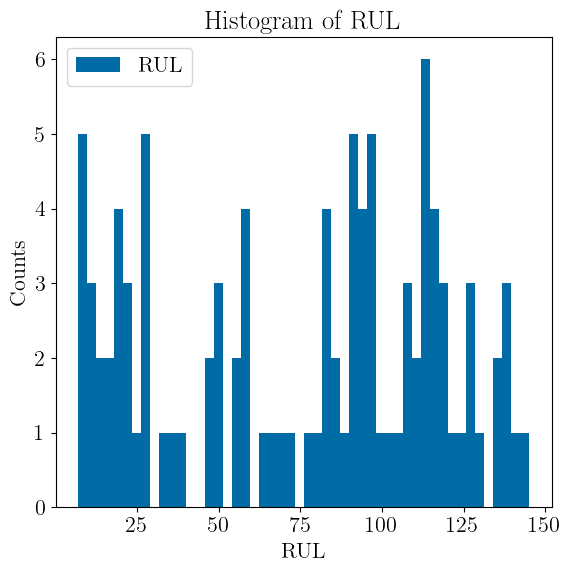

In [26]:
# Make a histogram of the RULs
df_RUL = pd.read_csv(os.path.join(path, 'RUL_FD001.txt'), sep=' ', header=None)
df_RUL.columns = ["RUL", "null"] # Investigate why I need this null col

RUL_fig = data_vis_hist(df_RUL, f"RUL", bins = 50)

Training on ~30 cycles looks good for this.

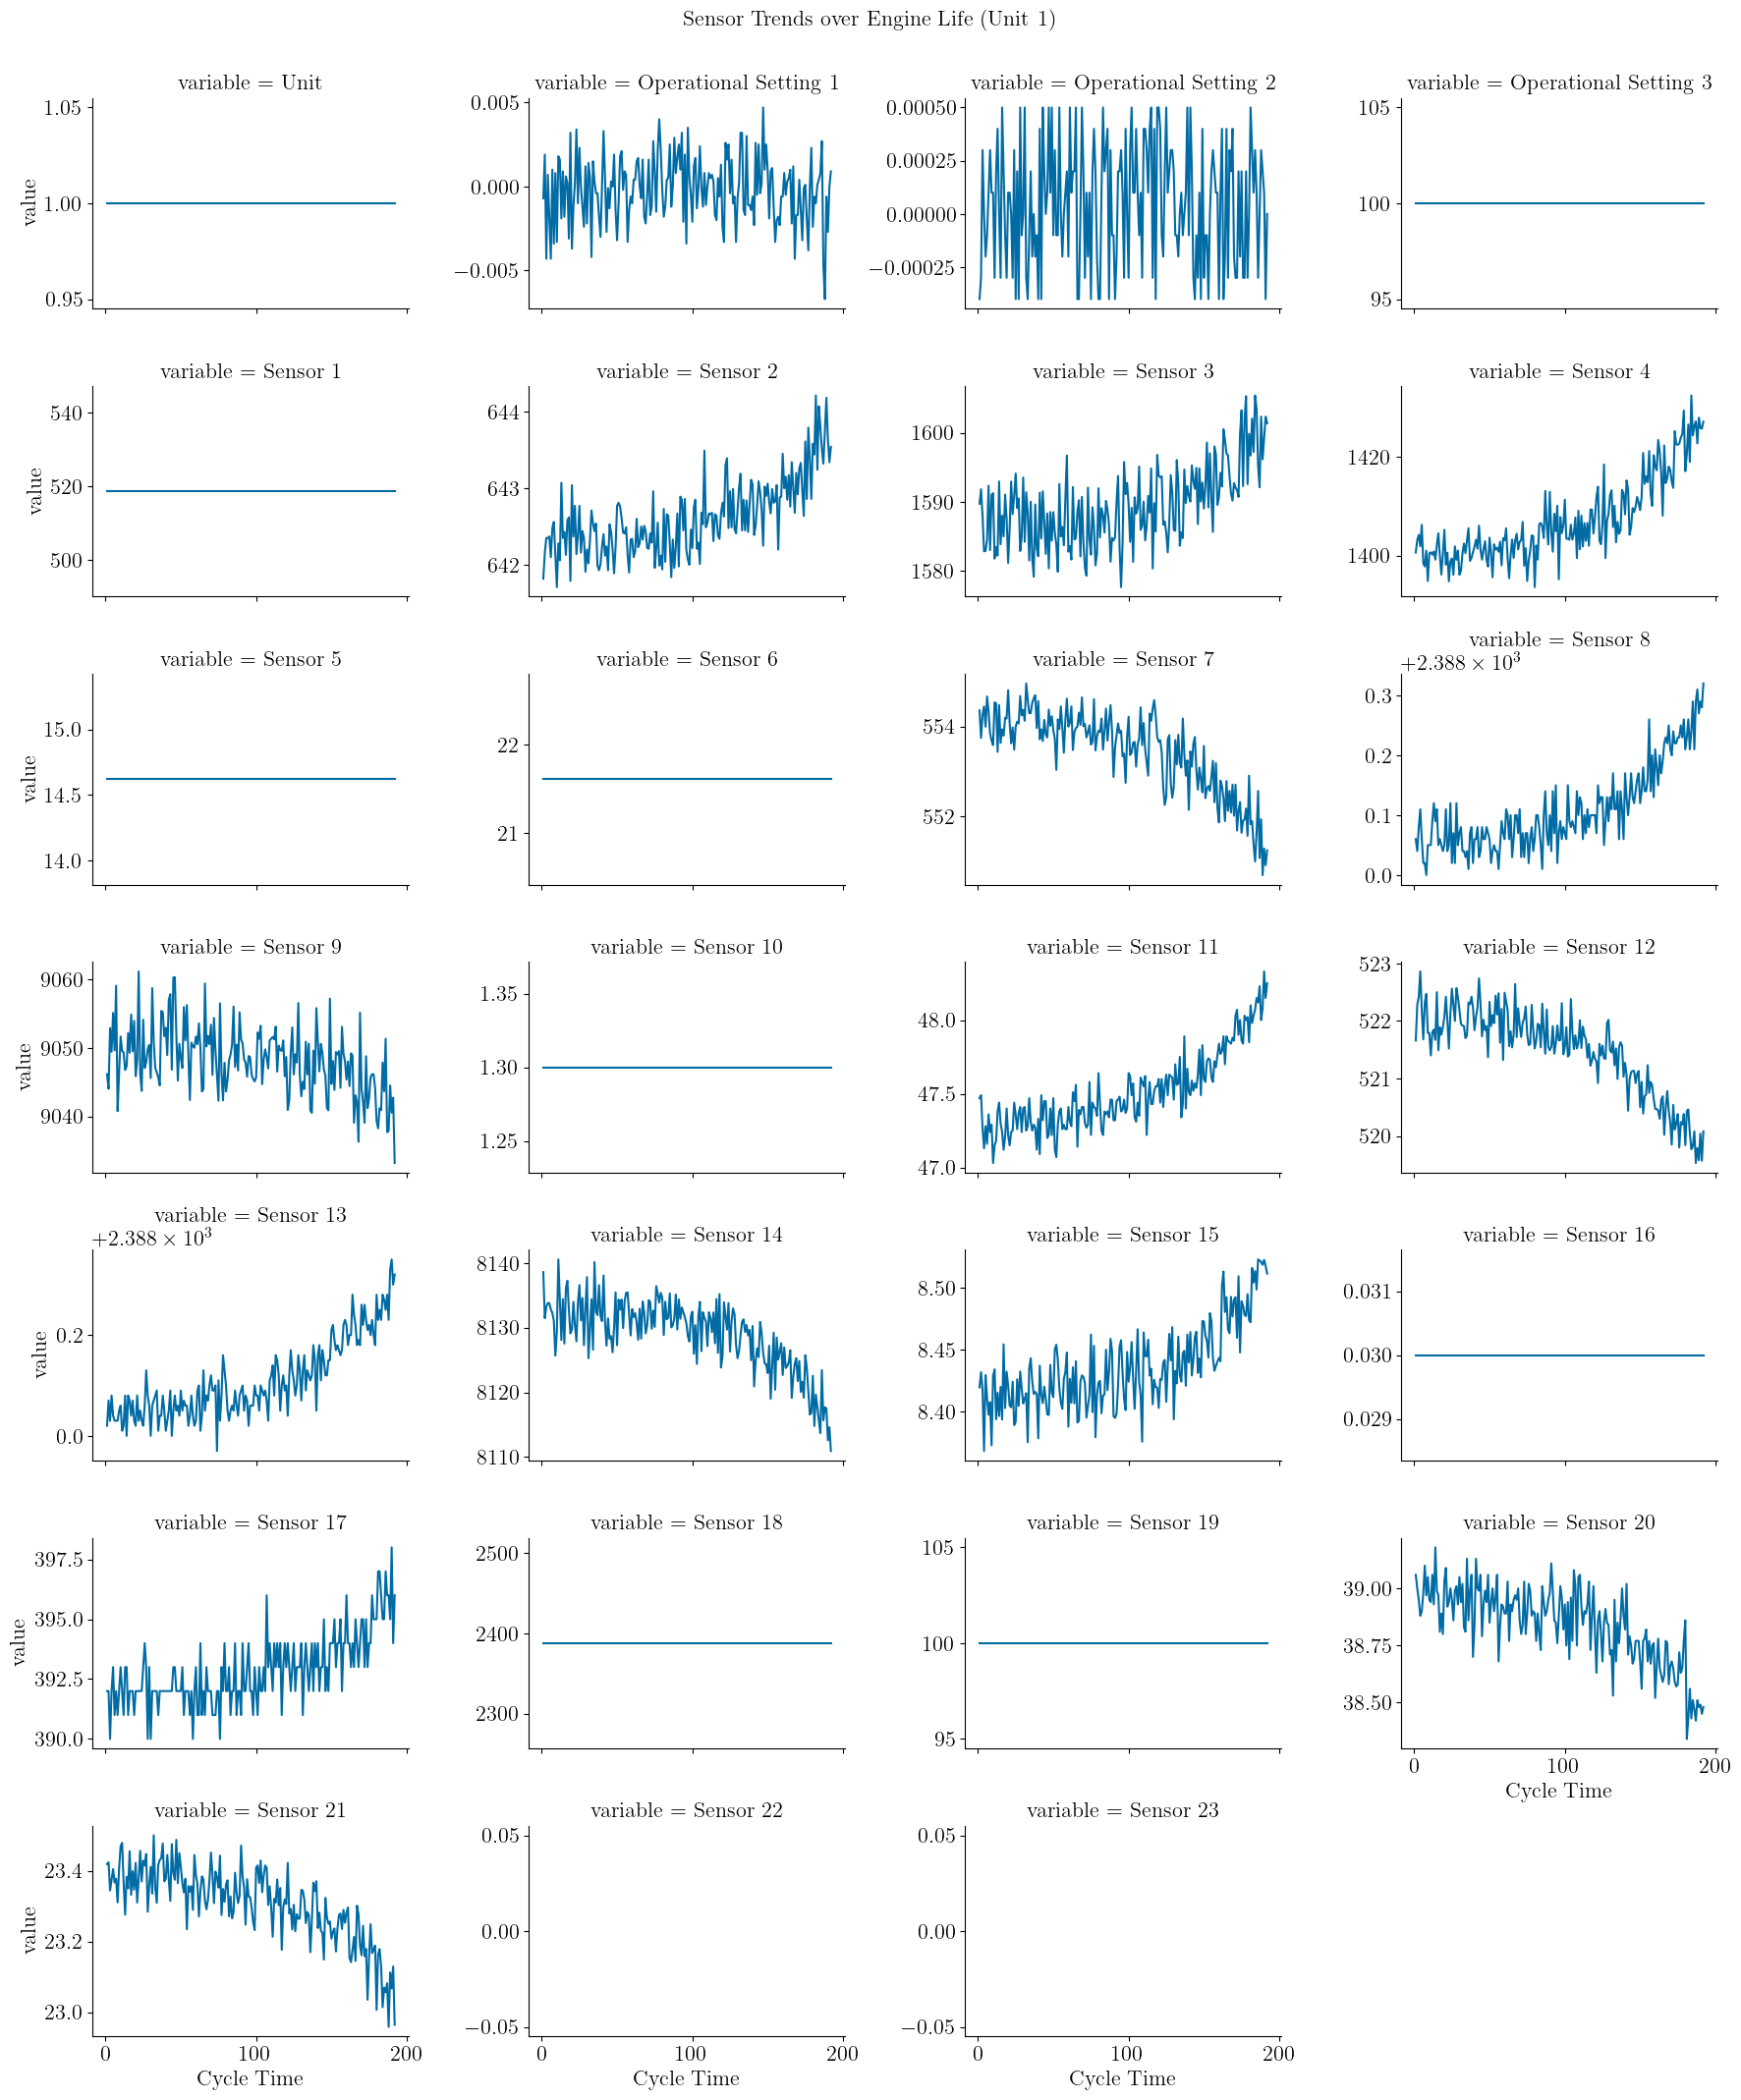

In [33]:
unit_data = df_train[df_train['Unit'] == 1]
relevant_sensors = ['Unit', 'Cycle Time'] + [f'Sensor {_+1}' for _ in range(22)]
plot_data = unit_data.melt(id_vars='Cycle Time', value_vars=col_names)

# Create a grid of plots
g = sns.FacetGrid(plot_data, col="variable", col_wrap=4, sharey=False, aspect=1.5)
g.map(sns.lineplot, "Cycle Time", "value")

# Add a title and adjust layout
g.fig.suptitle('Sensor Trends over Engine Life (Unit 1)', y=1.02, fontsize=16)
plt.show()

Sensors to drop: 1, 5, 6, 10, 16, 17, 18, 19, (22, 23?)

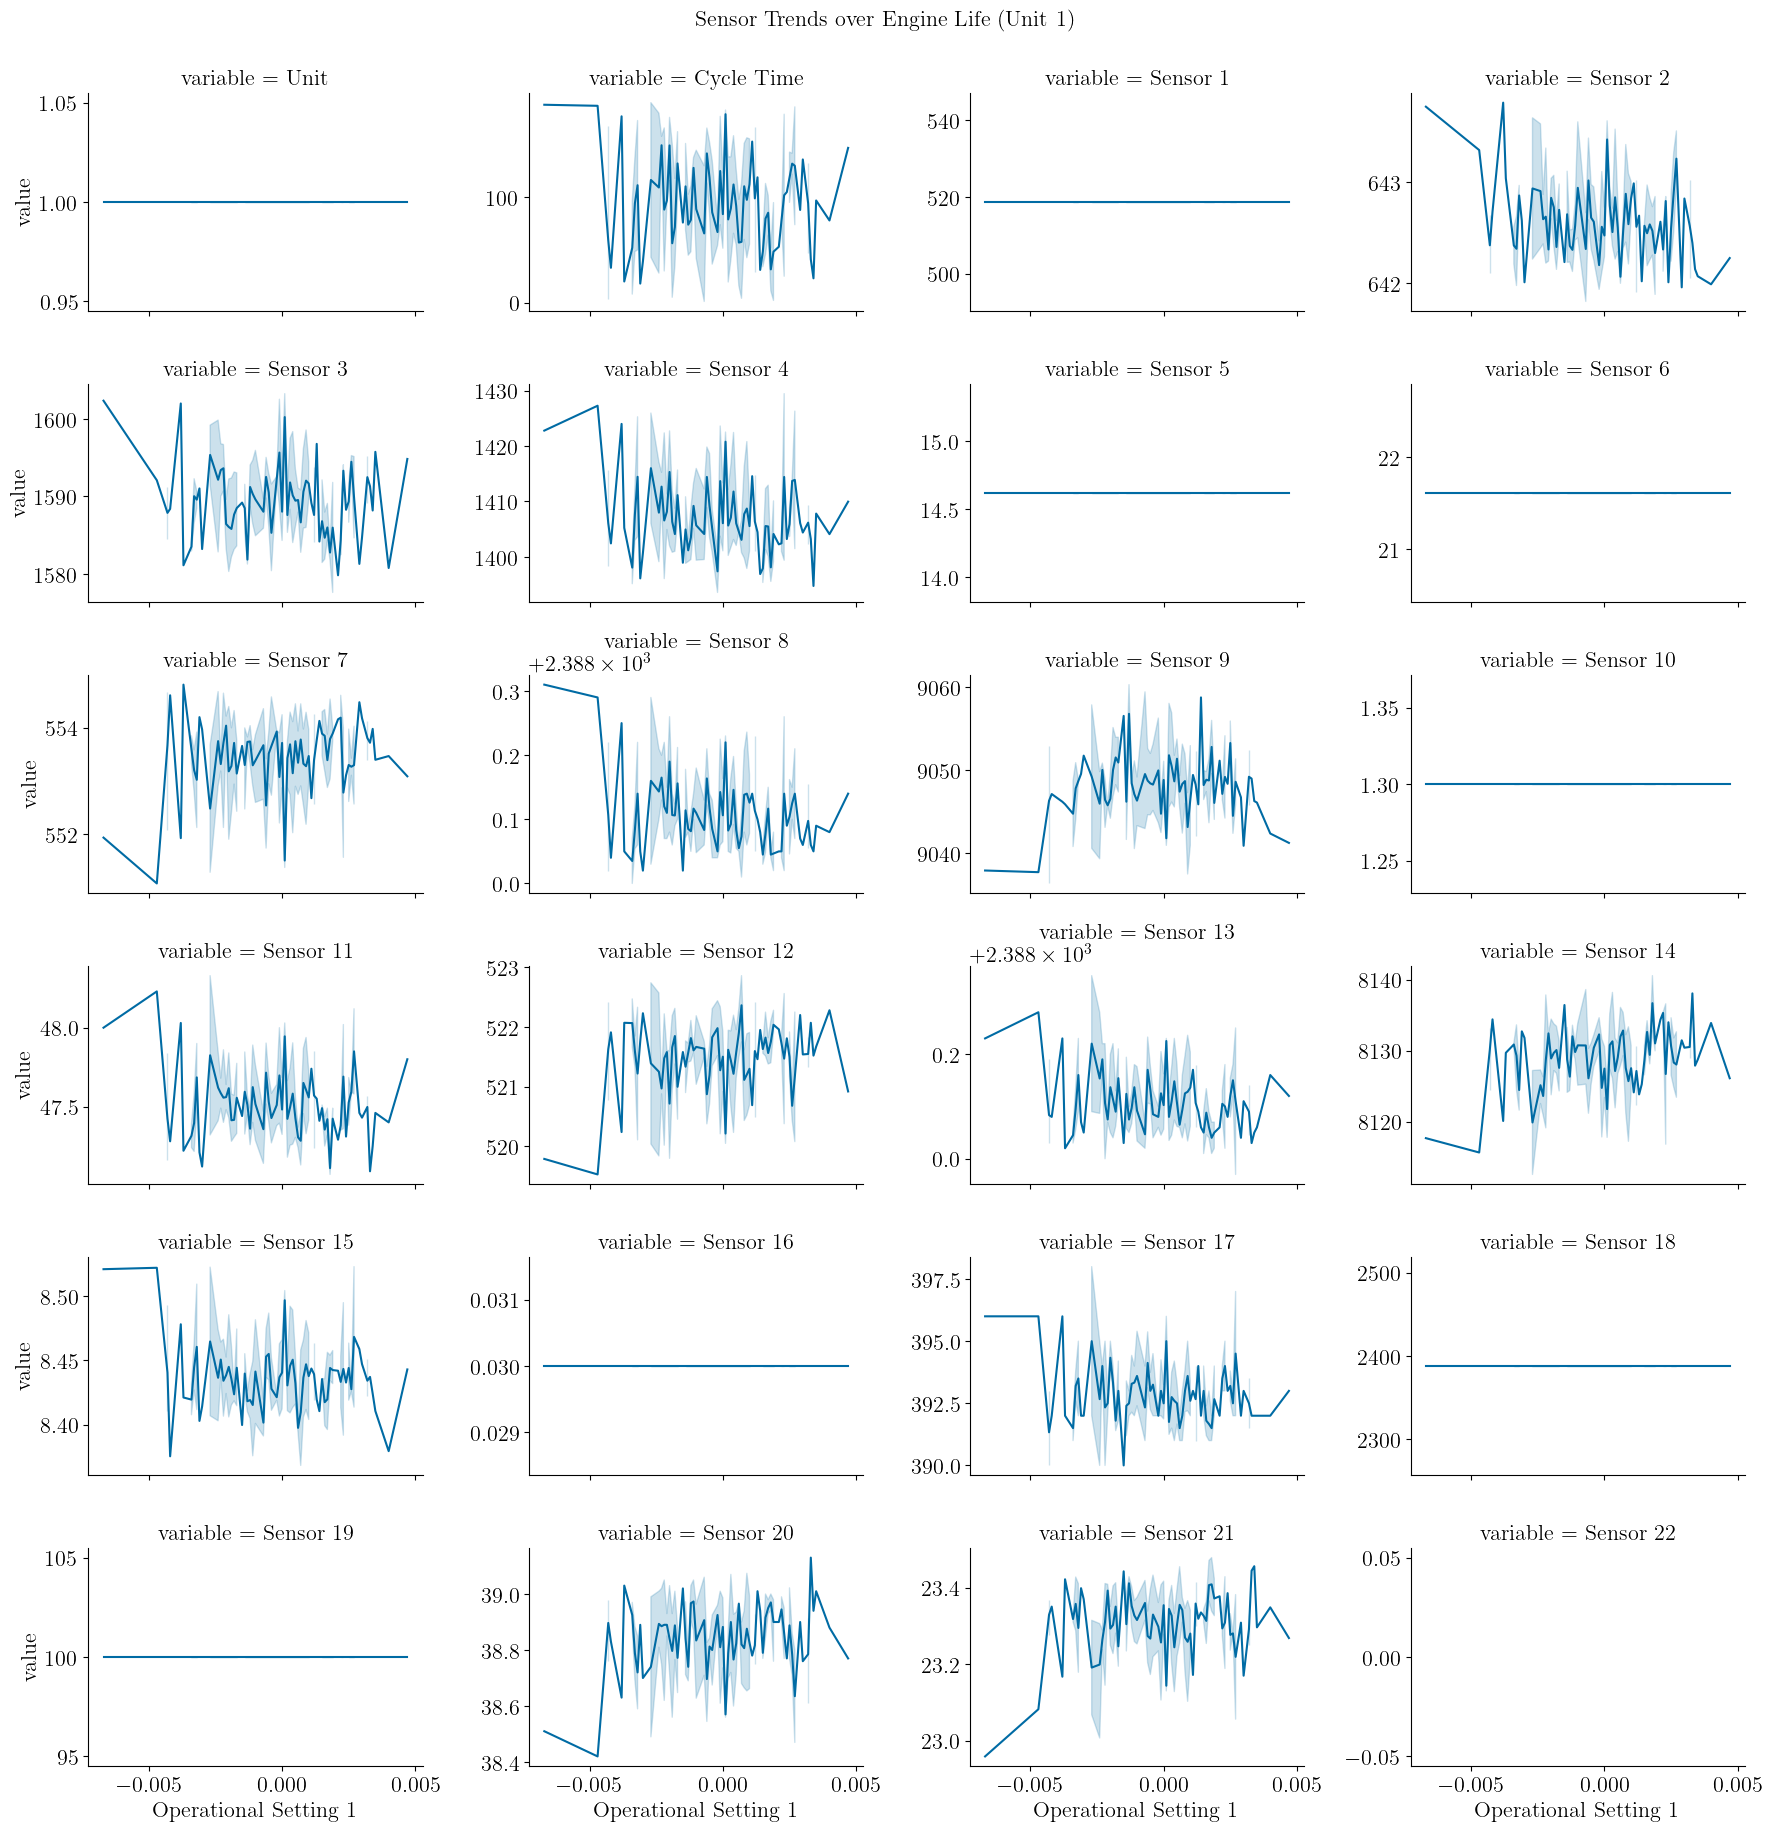

In [28]:
# Check to see if operational settings correlate to something
# Operational Setting 1

unit_data = df_train[df_train['Unit'] == 1]
relevant_sensors = ['Unit', 'Cycle Time'] + [f'Sensor {_+1}' for _ in range(22)]
plot_data = unit_data.melt(id_vars='Operational Setting 1', value_vars=relevant_sensors)

# Create a grid of plots
g = sns.FacetGrid(plot_data, col="variable", col_wrap=4, sharey=False, aspect=1.5)
g.map(sns.lineplot, "Operational Setting 1", "value")

# Add a title and adjust layout
g.fig.suptitle('Sensor Trends over Engine Life (Unit 1)', y=1.02, fontsize=16)
plt.show()

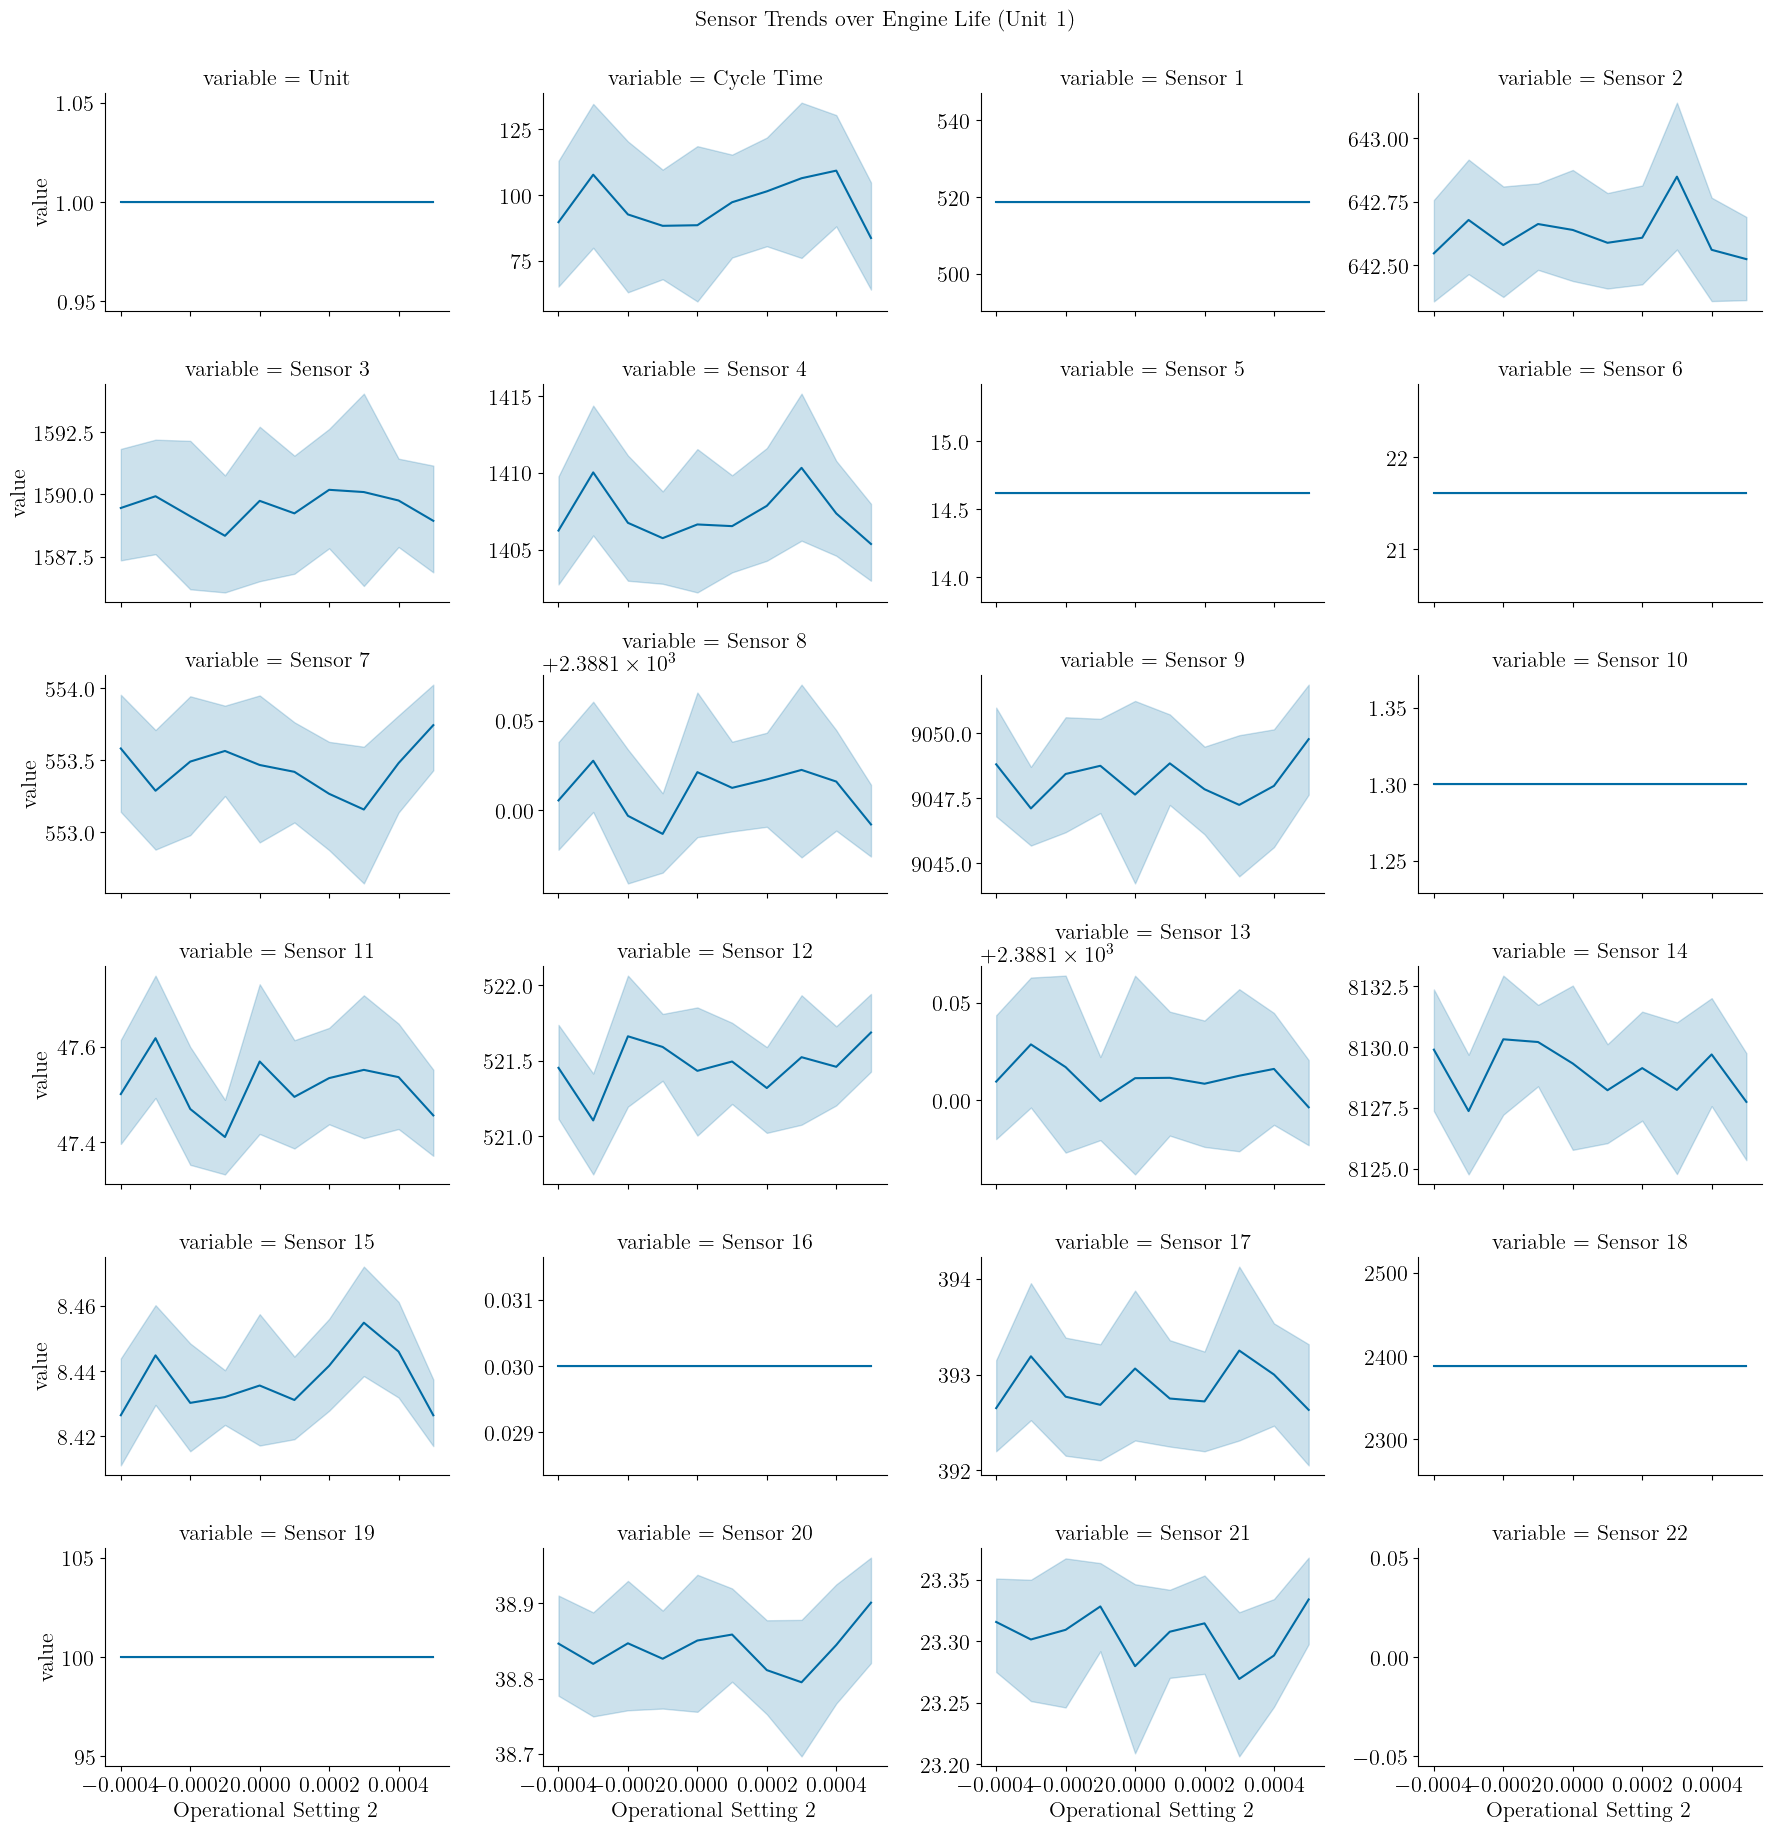

In [29]:
# Operational Setting 2

unit_data = df_train[df_train['Unit'] == 1]
relevant_sensors = ['Unit', 'Cycle Time'] + [f'Sensor {_+1}' for _ in range(22)]
plot_data = unit_data.melt(id_vars='Operational Setting 2', value_vars=relevant_sensors)

# Create a grid of plots
g = sns.FacetGrid(plot_data, col="variable", col_wrap=4, sharey=False, aspect=1.5)
g.map(sns.lineplot, "Operational Setting 2", "value")

# Add a title and adjust layout
g.fig.suptitle('Sensor Trends over Engine Life (Unit 1)', y=1.02, fontsize=16)
plt.show()

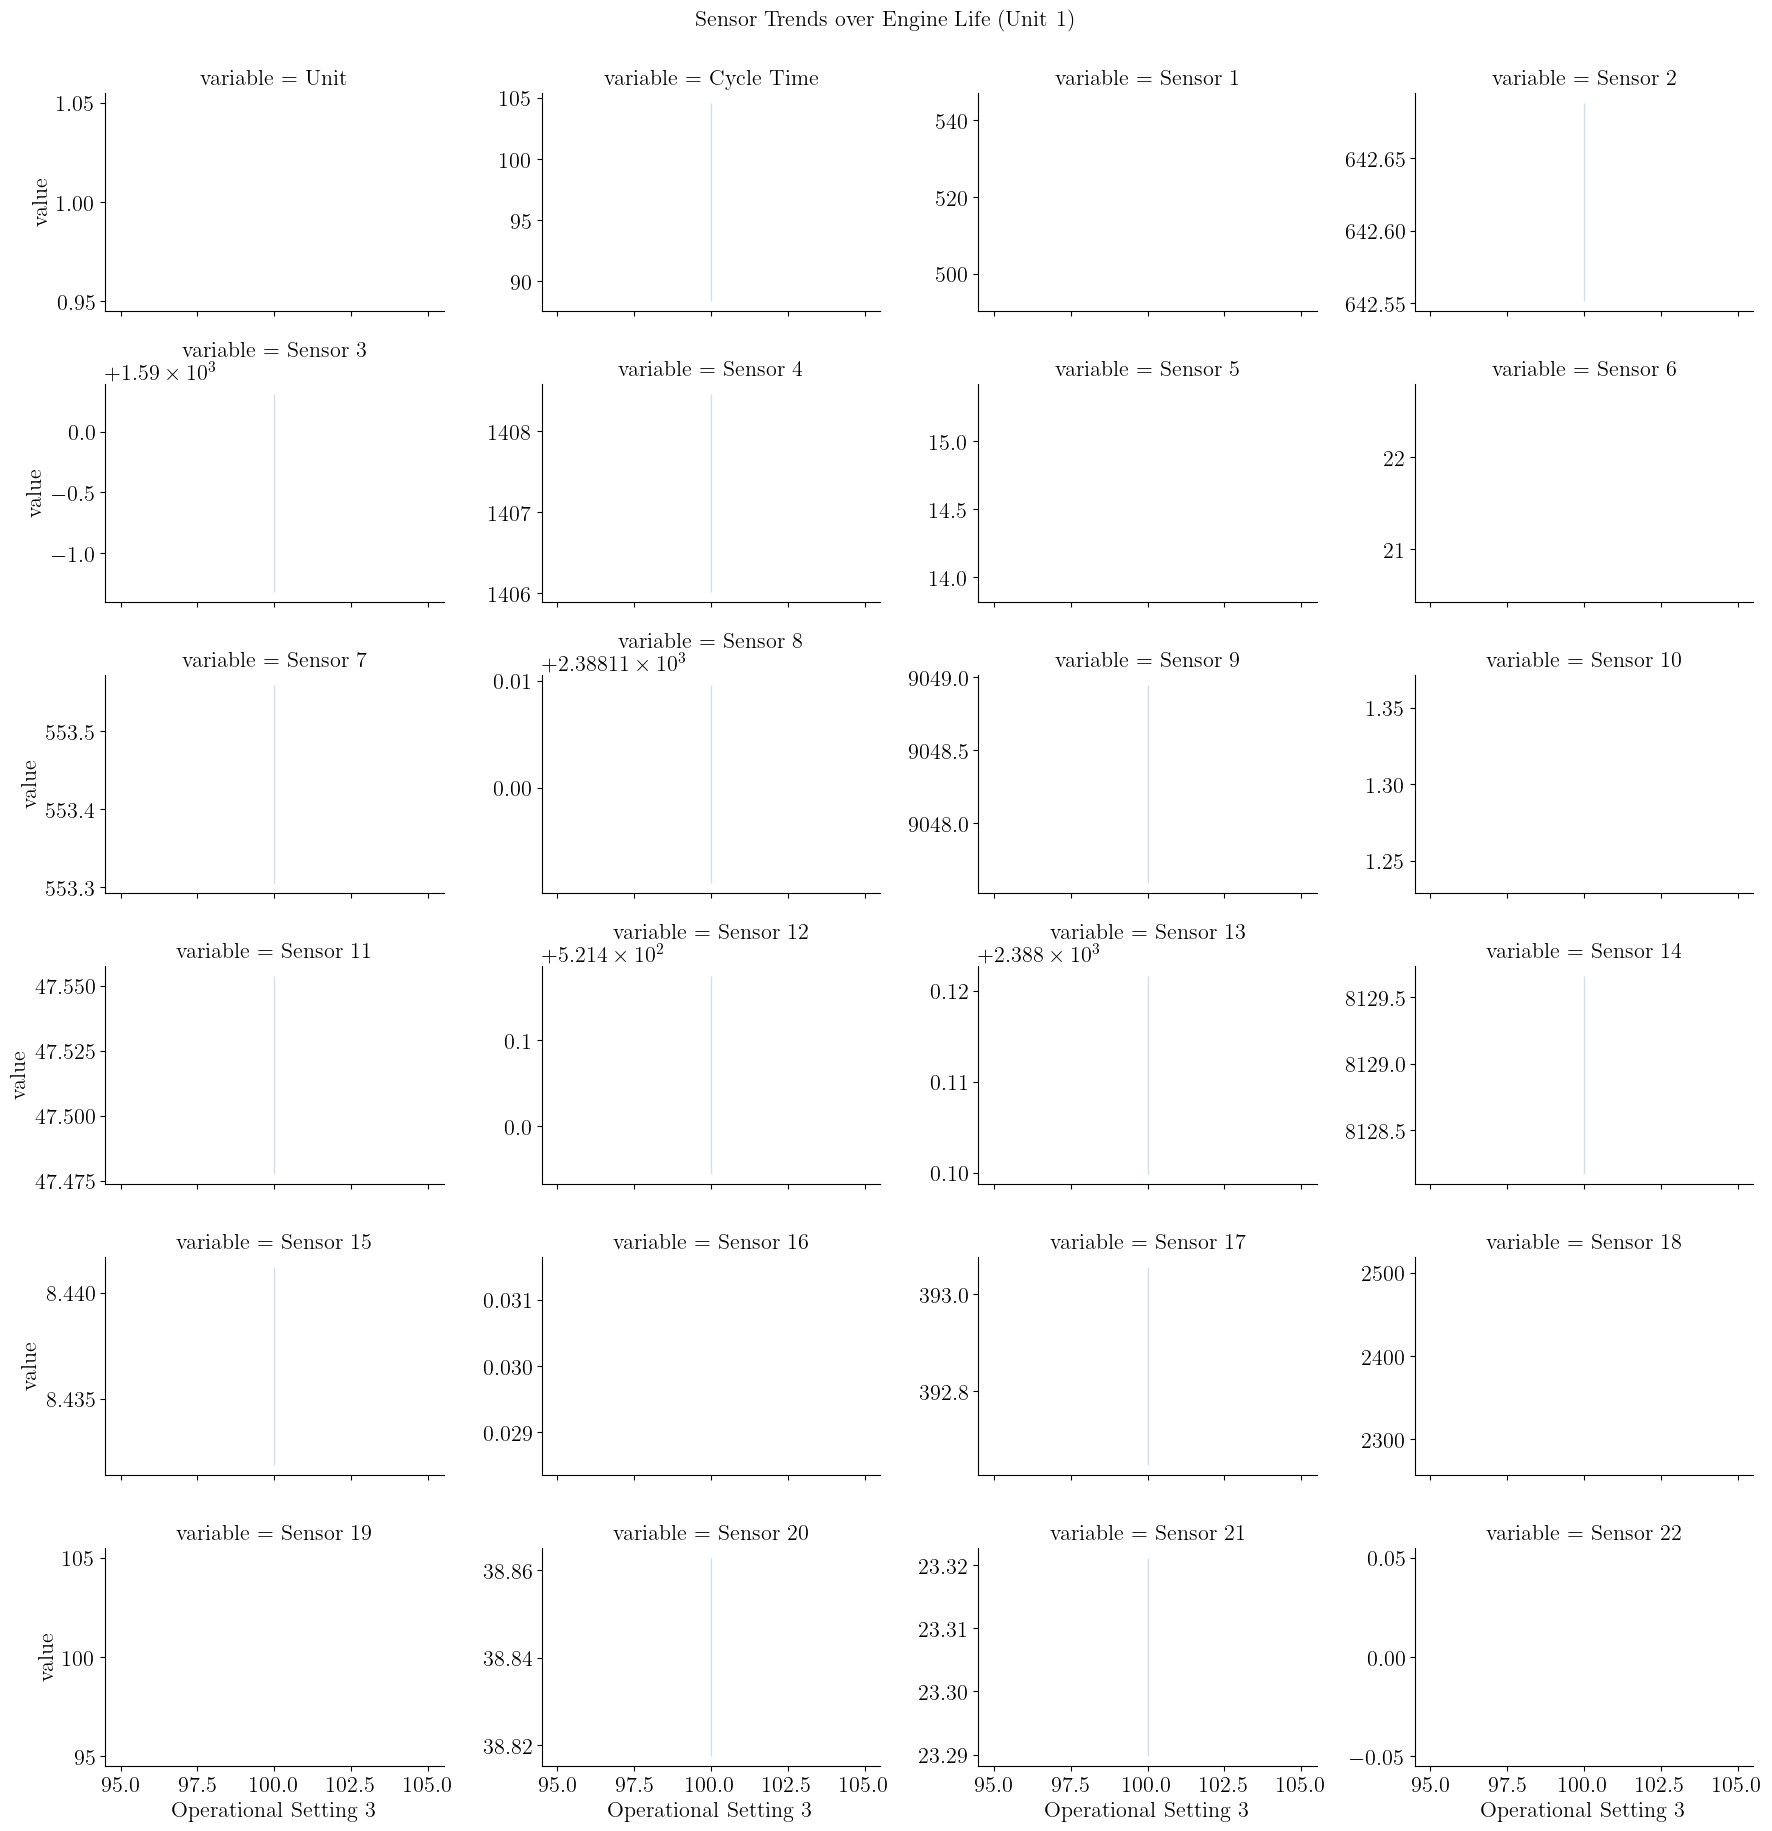

In [30]:
# Operational Setting 3

unit_data = df_train[df_train['Unit'] == 1]
relevant_sensors = ['Unit', 'Cycle Time'] + [f'Sensor {_+1}' for _ in range(22)]
plot_data = unit_data.melt(id_vars='Operational Setting 3', value_vars=relevant_sensors)

# Create a grid of plots
g = sns.FacetGrid(plot_data, col="variable", col_wrap=4, sharey=False, aspect=1.5)
g.map(sns.lineplot, "Operational Setting 3", "value")

# Add a title and adjust layout
g.fig.suptitle('Sensor Trends over Engine Life (Unit 1)', y=1.02, fontsize=16)
plt.show()